# HMAGAT-CS Training Metrics Plots

Этот notebook строит графики по direct batch-metrics CSV из training run, а если его нет, то использует legacy CSV, извлеченный из training log.

Доступные файлы:

- `train_hmagat_cs_sequence_32_scratch_batch_metrics.csv`
- `train_hmagat_cs_sequence_32_scratch_batch_loss.csv` (legacy fallback)
- `train_hmagat_cs_sequence_32_scratch_epoch_summary.csv`
- `train_hmagat_cs_sequence_32_scratch_metric_availability.csv`
- `train_hmagat_cs_sequence_32_scratch_validation_metrics.csv`

Важно:

- `accuracy` = supervised action-prediction accuracy
- `partial success rate` = доля агентов, реально дошедших до целей в rollout
- `success rate` = доля карт, решённых полностью

Если direct batch-metrics CSV присутствует, notebook использует `train_batch_loss` и `train_batch_accuracy` напрямую из него.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorboard.backend.event_processing import event_accumulator

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOG_DIR = PROJECT_ROOT / "datasets" / "hmagat_cs_lacam" / "logs"
BATCH_METRICS_CSV = LOG_DIR / "train_hmagat_cs_sequence_32_scratch_batch_metrics.csv"
LEGACY_BATCH_LOSS_CSV = LOG_DIR / "train_hmagat_cs_sequence_32_scratch_batch_loss.csv"
BATCH_LOSS_CSV = BATCH_METRICS_CSV if BATCH_METRICS_CSV.exists() else LEGACY_BATCH_LOSS_CSV
EPOCH_SUMMARY_CSV = LOG_DIR / "train_hmagat_cs_sequence_32_scratch_epoch_summary.csv"
AVAILABILITY_CSV = LOG_DIR / "train_hmagat_cs_sequence_32_scratch_metric_availability.csv"
VALIDATION_METRICS_CSV = LOG_DIR / "train_hmagat_cs_sequence_32_scratch_validation_metrics.csv"
TENSORBOARD_RUN_DIR = PROJECT_ROOT / "runs" / "hmagat_cs_sequence_32_scratch"

BATCH_METRICS_CSV, BATCH_LOSS_CSV, EPOCH_SUMMARY_CSV, AVAILABILITY_CSV, VALIDATION_METRICS_CSV, TENSORBOARD_RUN_DIR

(PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/datasets/hmagat_cs_lacam/logs/train_hmagat_cs_sequence_32_scratch_batch_metrics.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/datasets/hmagat_cs_lacam/logs/train_hmagat_cs_sequence_32_scratch_batch_metrics.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/datasets/hmagat_cs_lacam/logs/train_hmagat_cs_sequence_32_scratch_epoch_summary.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/datasets/hmagat_cs_lacam/logs/train_hmagat_cs_sequence_32_scratch_metric_availability.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/datasets/hmagat_cs_lacam/logs/train_hmagat_cs_sequence_32_scratch_validation_metrics.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/runs/hmagat_cs_sequence_32_scratch'))

In [2]:
availability_df = pd.read_csv(AVAILABILITY_CSV)
validation_metrics_df = pd.read_csv(VALIDATION_METRICS_CSV) if VALIDATION_METRICS_CSV.exists() else pd.DataFrame()
availability_df

,metric_name,granularity,source,available,notes
0,train_batch_loss,batch,direct_batch_metrics_csv,yes,Canonical source is train_hmagat_cs_sequence_3...
1,train_batch_accuracy,batch,direct_batch_metrics_csv,yes,Batch-level action-prediction accuracy from di...
2,mean_train_loss,epoch,combined_logs,yes,"Extracted from `Epoch X, Mean Loss: ..., Mean ..."
3,mean_train_accuracy,epoch,combined_logs,yes,"Extracted from `Epoch X, Mean Loss: ..., Mean ..."
4,validation_success_rate,epoch,validation_metrics_csv,no,Will be populated automatically after the next...


In [3]:
batch_loss_df = pd.read_csv(BATCH_LOSS_CSV)
epoch_summary_df = pd.read_csv(EPOCH_SUMMARY_CSV)
validation_metrics_df = pd.read_csv(VALIDATION_METRICS_CSV) if VALIDATION_METRICS_CSV.exists() else validation_metrics_df

batch_loss_df["global_step"] = range(1, len(batch_loss_df) + 1)
batch_loss_df["loss_rolling_25"] = batch_loss_df["train_batch_loss"].rolling(window=25, min_periods=1).mean()
batch_loss_df["loss_rolling_100"] = batch_loss_df["train_batch_loss"].rolling(window=100, min_periods=1).mean()
if "train_batch_accuracy" in batch_loss_df.columns:
    batch_loss_df["train_batch_accuracy"] = pd.to_numeric(batch_loss_df["train_batch_accuracy"], errors="coerce")
    batch_loss_df["accuracy_rolling_25"] = batch_loss_df["train_batch_accuracy"].rolling(window=25, min_periods=1).mean()

print(f"Batch loss rows: {len(batch_loss_df)}")
print(f"Epoch summary rows: {len(epoch_summary_df)}")
print(f"Validation metric rows: {len(validation_metrics_df)}")
batch_loss_df.head()

Batch loss rows: 21952
Epoch summary rows: 1
Validation metric rows: 4


,timestamp,optimization_step,epoch,batch_idx,total_batches,progress_pct,elapsed_text,eta_text,train_batch_loss,train_batch_accuracy,source_log,line_number,global_step,loss_rolling_25,loss_rolling_100,accuracy_rolling_25
0,2026-05-17 01:45:27.908,0,0,1,1039,0.10,2m 43s,47h 15m 16s,1.654429,NaN,train_hmagat_cs_sequence_32_scratch.log,38.0,1,1.654429,1.654429,NaN
1,2026-05-17 01:46:04.831,1,0,5,1039,0.48,3m 20s,11h 32m 7s,1.493197,NaN,train_hmagat_cs_sequence_32_scratch.log,39.0,2,1.573813,1.573813,NaN
2,2026-05-17 01:46:38.698,2,0,9,1039,0.87,3m 54s,7h 27m 37s,1.267489,NaN,train_hmagat_cs_sequence_32_scratch.log,40.0,3,1.471705,1.471705,NaN
3,2026-05-17 01:47:14.177,3,0,13,1039,1.25,4m 30s,5h 55m 21s,1.178313,NaN,train_hmagat_cs_sequence_32_scratch.log,41.0,4,1.398357,1.398357,NaN
4,2026-05-17 01:47:48.507,4,0,17,1039,1.64,5m 4s,5h 5m 5s,1.206399,NaN,train_hmagat_cs_sequence_32_scratch.log,42.0,5,1.359965,1.359965,NaN


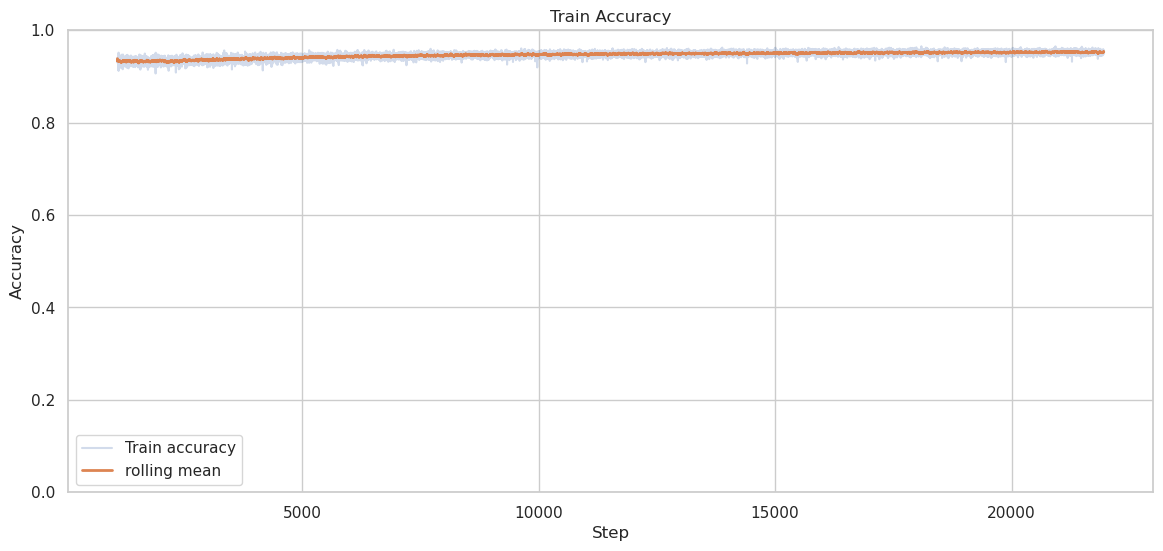

In [4]:
plot_df = batch_loss_df[
    (batch_loss_df["global_step"] >= 0)
    & batch_loss_df["train_batch_accuracy"].between(0.0, 1.0, inclusive="both")
].copy()

plot_df["accuracy_rolling_25_filtered"] = (
    plot_df["train_batch_accuracy"].rolling(window=25, min_periods=1).mean()
)
# plot_df["accuracy_rolling_100_filtered"] = (
#     plot_df["train_batch_accuracy"].rolling(window=100, min_periods=1).mean()
# )

fig, ax = plt.subplots()
ax.plot(
    plot_df["global_step"],
    plot_df["train_batch_accuracy"],
    alpha=0.25,
    label="Train accuracy",
)
ax.plot(
    plot_df["global_step"],
    plot_df["accuracy_rolling_25_filtered"],
    linewidth=2,
    label="rolling mean",
)
# ax.plot(
#     plot_df["global_step"],
#     plot_df["accuracy_rolling_100_filtered"],
#     linewidth=2,
#     label="rolling mean (100)",
# )
ax.set_title("Train Accuracy")
ax.set_xlabel("Step")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.show()

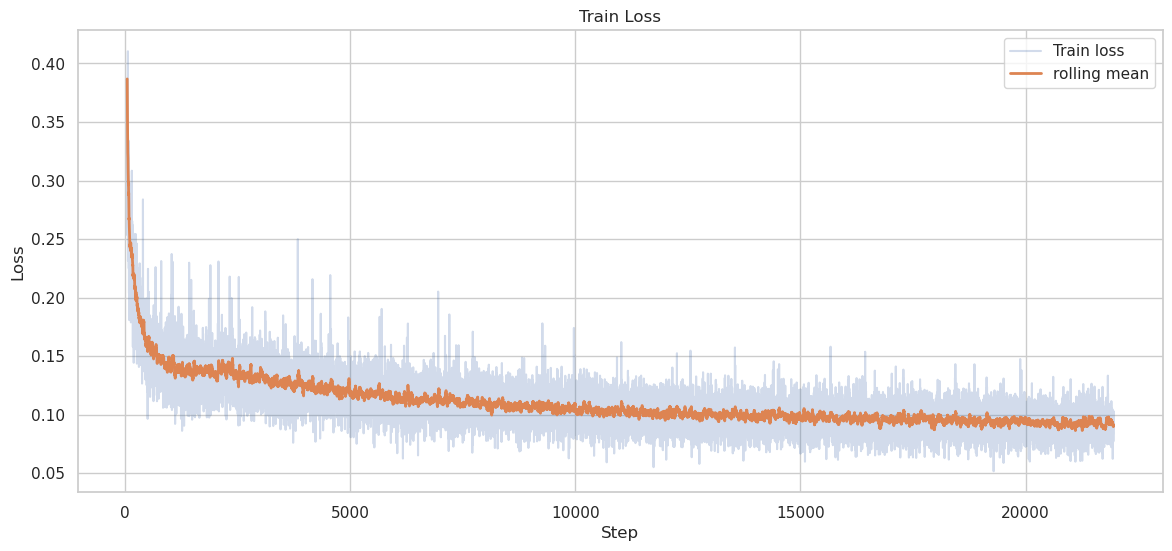

In [5]:
plot_df = batch_loss_df[batch_loss_df["global_step"] >= 50]

fig, ax = plt.subplots()
ax.plot(plot_df["global_step"], plot_df["train_batch_loss"], alpha=0.25, label="Train loss")
ax.plot(plot_df["global_step"], plot_df["loss_rolling_25"], linewidth=2, label="rolling mean")
# ax.plot(plot_df["global_step"], plot_df["loss_rolling_100"], linewidth=2, label="rolling mean (100)")
ax.set_title("Train Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

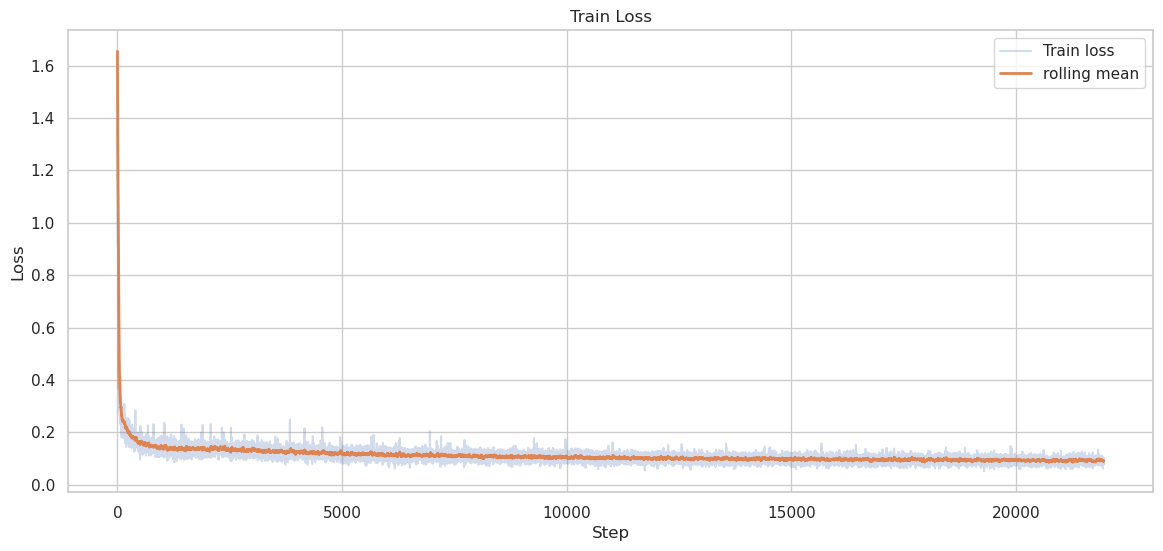

In [6]:
fig, ax = plt.subplots()
ax.plot(batch_loss_df["global_step"], batch_loss_df["train_batch_loss"], alpha=0.25, label="Train loss")
ax.plot(batch_loss_df["global_step"], batch_loss_df["loss_rolling_25"], linewidth=2, label="rolling mean")
# ax.plot(batch_loss_df["global_step"], batch_loss_df["loss_rolling_100"], linewidth=2, label="rolling mean (100)")
ax.set_title("Train Loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

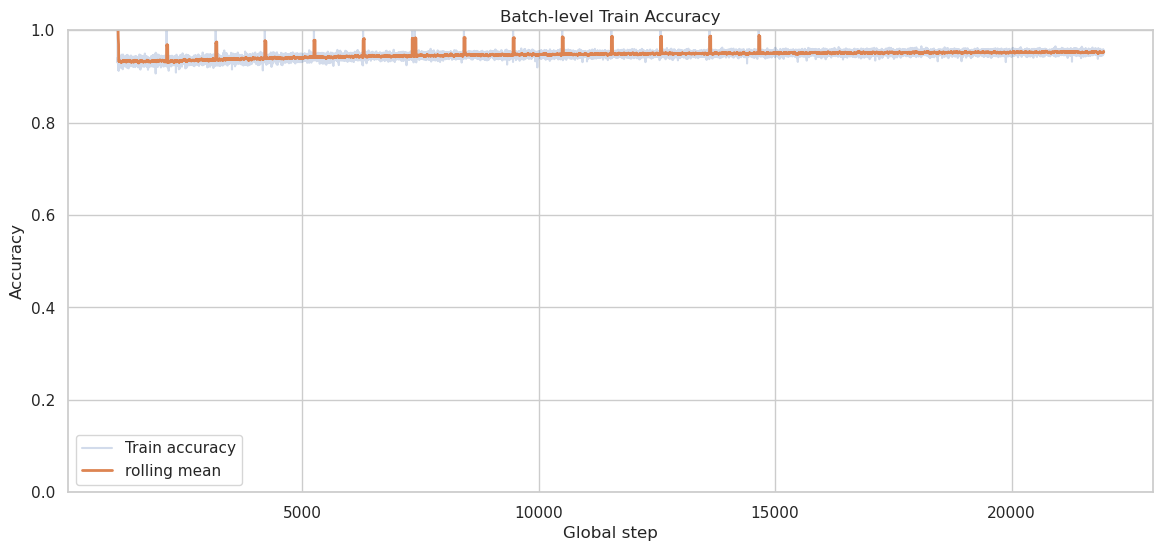

In [7]:
if "train_batch_accuracy" not in batch_loss_df.columns or batch_loss_df["train_batch_accuracy"].dropna().empty:
    print("Batch-level train accuracy is not available in the selected CSV yet.")
else:
    fig, ax = plt.subplots()
    ax.plot(batch_loss_df["global_step"], batch_loss_df["train_batch_accuracy"], alpha=0.25, label="Train accuracy")
    ax.plot(batch_loss_df["global_step"], batch_loss_df["accuracy_rolling_25"], linewidth=2, label="rolling mean")
    ax.set_title("Batch-level Train Accuracy")
    ax.set_xlabel("Global step")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.0)
    ax.legend()
    plt.show()


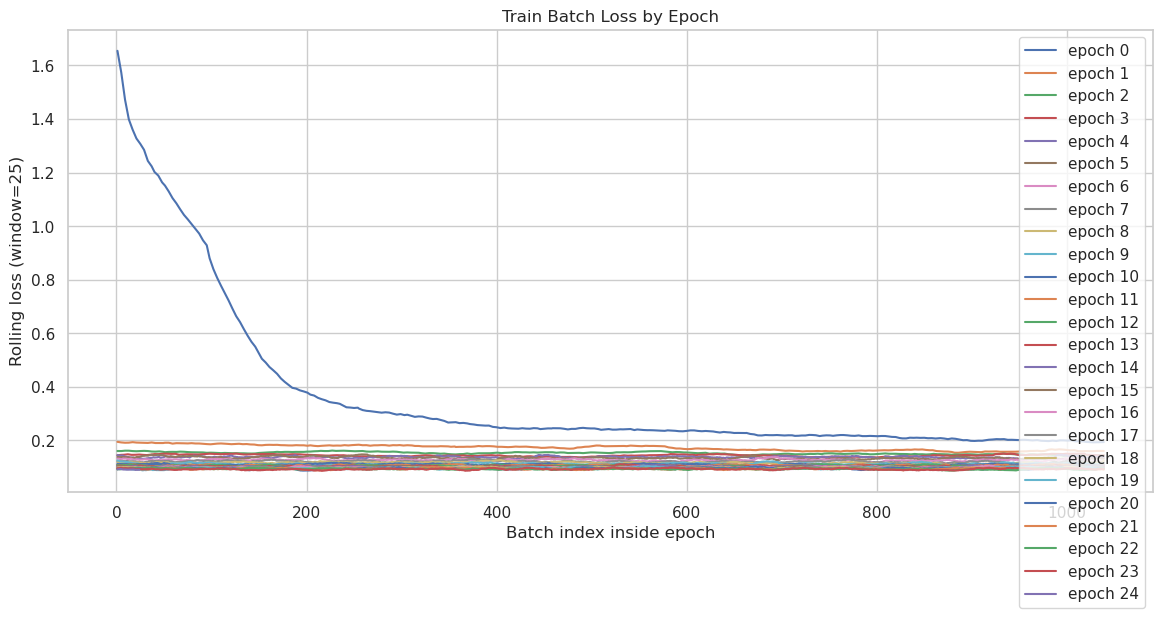

In [8]:
fig, ax = plt.subplots()
for epoch, epoch_df in batch_loss_df.groupby("epoch"):
    ax.plot(epoch_df["batch_idx"], epoch_df["loss_rolling_25"], label=f"epoch {epoch}")
ax.set_title("Train Batch Loss by Epoch")
ax.set_xlabel("Batch index inside epoch")
ax.set_ylabel("Rolling loss (window=25)")
ax.legend()
plt.show()

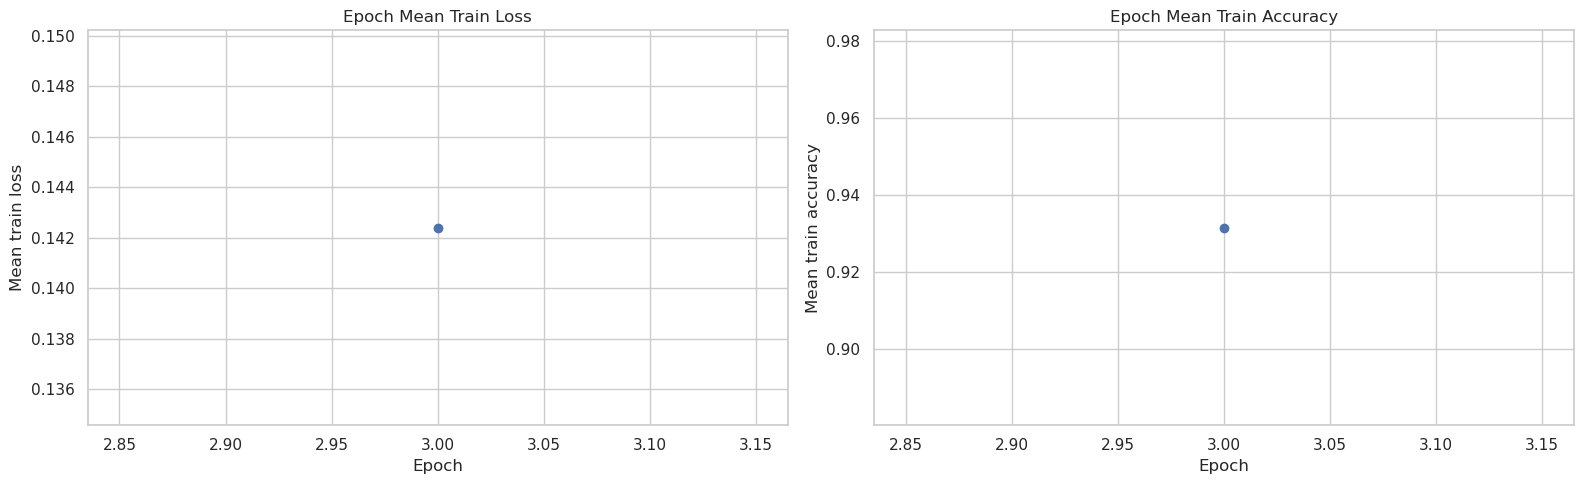

In [9]:
if epoch_summary_df.empty:
    print("Epoch-level mean loss/accuracy lines are not present in the current log yet.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(epoch_summary_df["epoch"], epoch_summary_df["mean_train_loss"], marker="o")
    axes[0].set_title("Epoch Mean Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Mean train loss")

    axes[1].plot(epoch_summary_df["epoch"], epoch_summary_df["mean_train_accuracy"], marker="o")
    axes[1].set_title("Epoch Mean Train Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean train accuracy")

    plt.tight_layout()
    plt.show()

In [10]:
batch_accuracy_available = availability_df.loc[
    availability_df["metric_name"] == "train_batch_accuracy", "available"
].iloc[0]

if batch_accuracy_available == "yes":
    print("Batch-level train accuracy is available in the source data.")
else:
    print("Batch-level train accuracy is not present in the current source data yet.")

Batch-level train accuracy is available in the source data.


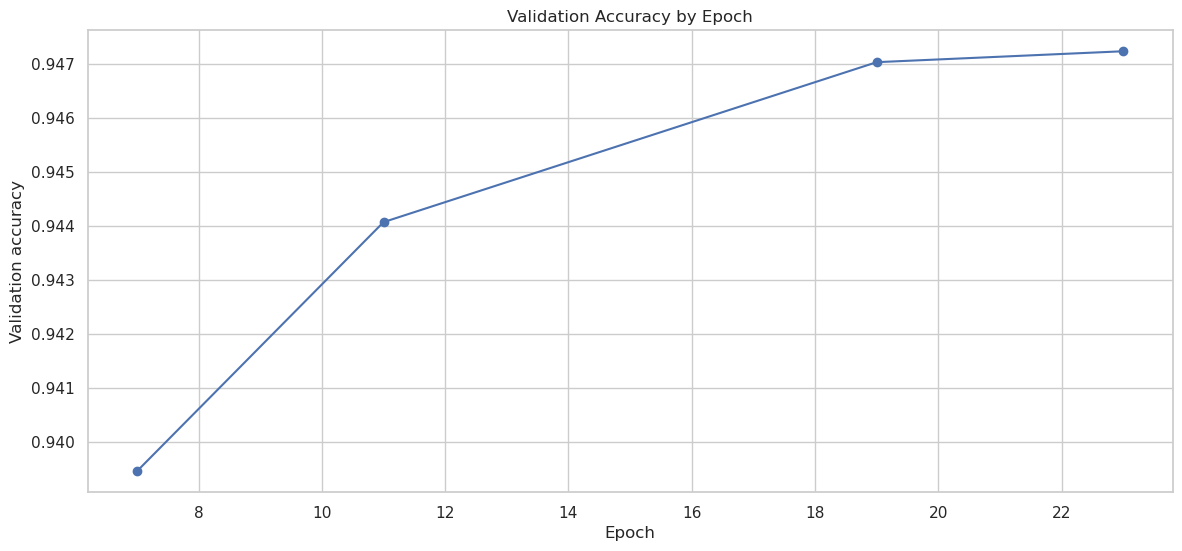

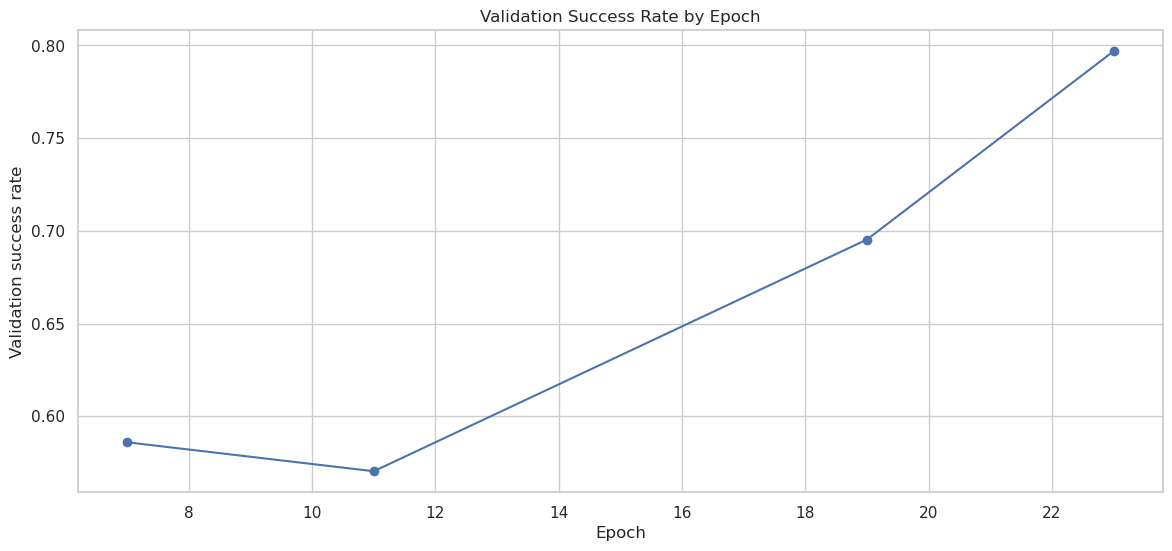

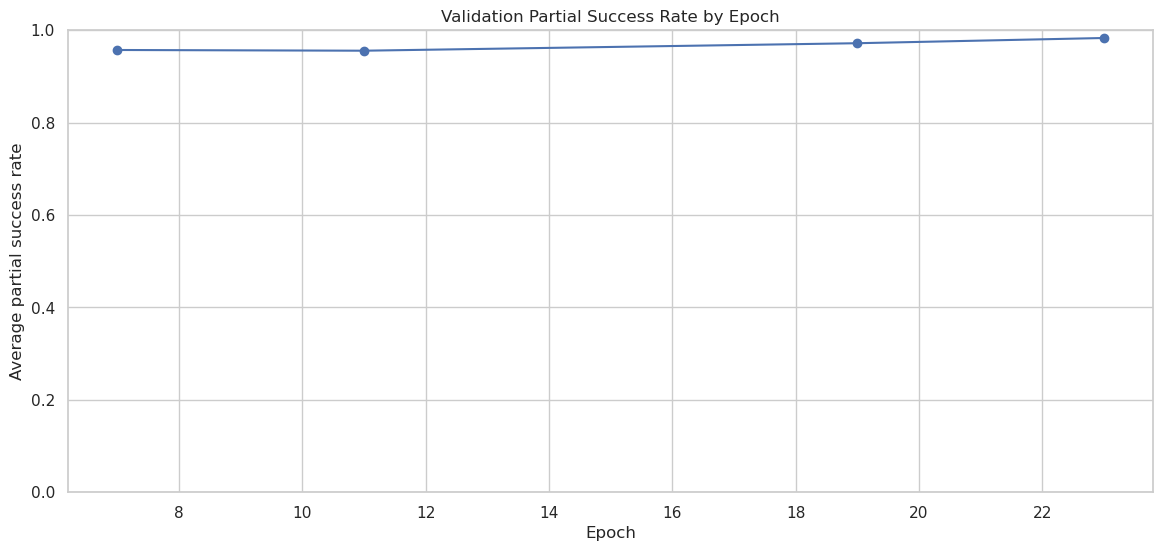

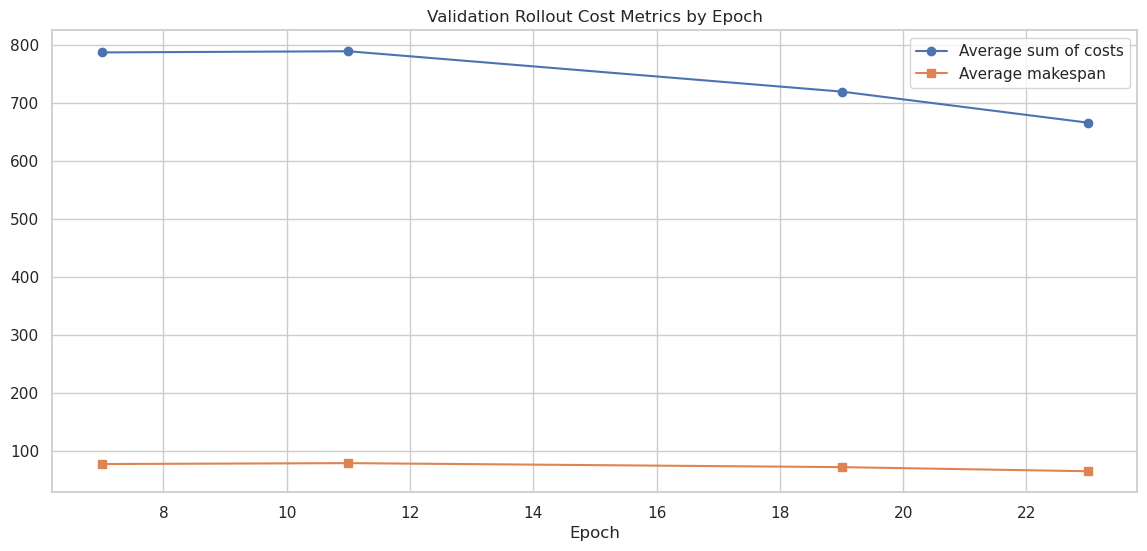

In [11]:
if validation_metrics_df.empty:
    print("Validation metrics CSV is not populated yet. After the next validation epoch on updated code, epoch-level validation curves will appear here.")
else:
    validation_plot_df = validation_metrics_df.copy()
    for column in [
        "validation_accuracy",
        "validation_success_rate",
        "validation_average_partial_success_rate",
        "validation_average_sum_of_costs",
        "validation_average_makespan",
    ]:
        if column in validation_plot_df.columns:
            validation_plot_df[column] = pd.to_numeric(validation_plot_df[column], errors="coerce")

    if "validation_accuracy" in validation_plot_df.columns and not validation_plot_df["validation_accuracy"].dropna().empty:
        fig, ax = plt.subplots()
        ax.plot(validation_plot_df["epoch"], validation_plot_df["validation_accuracy"], marker="o")
        ax.set_title("Validation Accuracy by Epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation accuracy")
        plt.show()

    if "validation_success_rate" in validation_plot_df.columns and not validation_plot_df["validation_success_rate"].dropna().empty:
        fig, ax = plt.subplots()
        ax.plot(validation_plot_df["epoch"], validation_plot_df["validation_success_rate"], marker="o")
        ax.set_title("Validation Success Rate by Epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation success rate")
        plt.show()

    if "validation_average_partial_success_rate" in validation_plot_df.columns and not validation_plot_df["validation_average_partial_success_rate"].dropna().empty:
        fig, ax = plt.subplots()
        ax.plot(validation_plot_df["epoch"], validation_plot_df["validation_average_partial_success_rate"], marker="o")
        ax.set_title("Validation Partial Success Rate by Epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Average partial success rate")
        ax.set_ylim(0.0, 1.0)
        plt.show()

    rollout_metric_cols = []
    if "validation_average_sum_of_costs" in validation_plot_df.columns:
        rollout_metric_cols.append("validation_average_sum_of_costs")
    if "validation_average_makespan" in validation_plot_df.columns:
        rollout_metric_cols.append("validation_average_makespan")

    if rollout_metric_cols:
        fig, ax = plt.subplots()
        if "validation_average_sum_of_costs" in validation_plot_df.columns:
            ax.plot(validation_plot_df["epoch"], validation_plot_df["validation_average_sum_of_costs"], marker="o", label="Average sum of costs")
        if "validation_average_makespan" in validation_plot_df.columns:
            ax.plot(validation_plot_df["epoch"], validation_plot_df["validation_average_makespan"], marker="s", label="Average makespan")
        ax.set_title("Validation Rollout Cost Metrics by Epoch")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()

    validation_plot_df


## TensorBoard Scalars

Этот блок читает `tfevents` напрямую и строит train loss/accuracy по плотным batch-level scalar events, а также epoch-level train/validation accuracy и train loss.


In [12]:
TB_TAGS = [
    "train_batch_loss",
    "train_batch_accuracy",
    "train_loss",
    "train_accuracy",
    "validation_accuracy",
    "validation_success_rate",
]

def load_tensorboard_scalar_df(run_dir: Path, tags: list[str]) -> pd.DataFrame:
    rows = []
    for event_path in sorted(run_dir.glob("events.out.tfevents*")):
        accumulator = event_accumulator.EventAccumulator(str(event_path))
        accumulator.Reload()
        scalar_tags = set(accumulator.Tags().get("scalars", []))
        process_id = event_path.name.split(".")[-2]
        for tag in tags:
            if tag not in scalar_tags:
                continue
            for scalar_event in accumulator.Scalars(tag):
                rows.append(
                    {
                        "event_file": event_path.name,
                        "process_id": process_id,
                        "tag": tag,
                        "event_step": int(scalar_event.step),
                        "wall_time": float(scalar_event.wall_time),
                        "value": float(scalar_event.value),
                    }
                )
    tb_df = pd.DataFrame(rows)
    if tb_df.empty:
        return tb_df
    tb_df = tb_df.sort_values(["tag", "wall_time", "event_step", "event_file"]).reset_index(drop=True)
    tb_df["event_index"] = tb_df.groupby("tag").cumcount() + 1
    return tb_df

tb_df = load_tensorboard_scalar_df(TENSORBOARD_RUN_DIR, TB_TAGS)
print(f"TensorBoard scalar rows: {len(tb_df)}")
if tb_df.empty:
    print("No TensorBoard scalar events found yet.")
else:
    display(tb_df.groupby("tag").agg(points=("value", "size"), first_step=("event_step", "min"), last_step=("event_step", "max"), last_value=("value", "last")))
tb_df.head()

TensorBoard scalar rows: 43882


,points,first_step,last_step,last_value
tag,,,,
train_accuracy,23,0,23,0.952485
train_batch_accuracy,21913,0,7296,0.952560
train_batch_loss,21913,0,7296,0.091053
train_loss,23,0,23,0.092791
validation_accuracy,5,3,23,0.947231
validation_success_rate,5,3,23,0.796875


,event_file,process_id,tag,event_step,wall_time,value,event_index
0,events.out.tfevents.1778982163.94b573a5842c.83...,8344,train_accuracy,0,1.778992e+09,0.861177,1
1,events.out.tfevents.1778982163.94b573a5842c.83...,8344,train_accuracy,1,1.779002e+09,0.919110,2
2,events.out.tfevents.1778982163.94b573a5842c.83...,8344,train_accuracy,2,1.779012e+09,0.926706,3
3,events.out.tfevents.1779011941.94b573a5842c.94...,9439,train_accuracy,3,1.779023e+09,0.931567,4
4,events.out.tfevents.1779023588.94b573a5842c.16...,16308,train_accuracy,4,1.779033e+09,0.933574,5


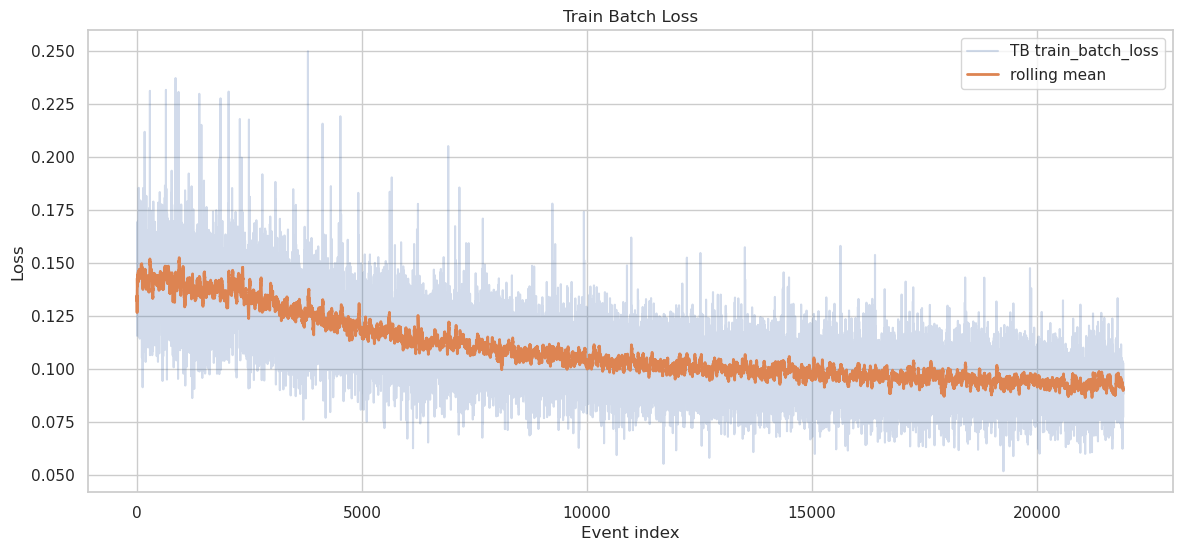

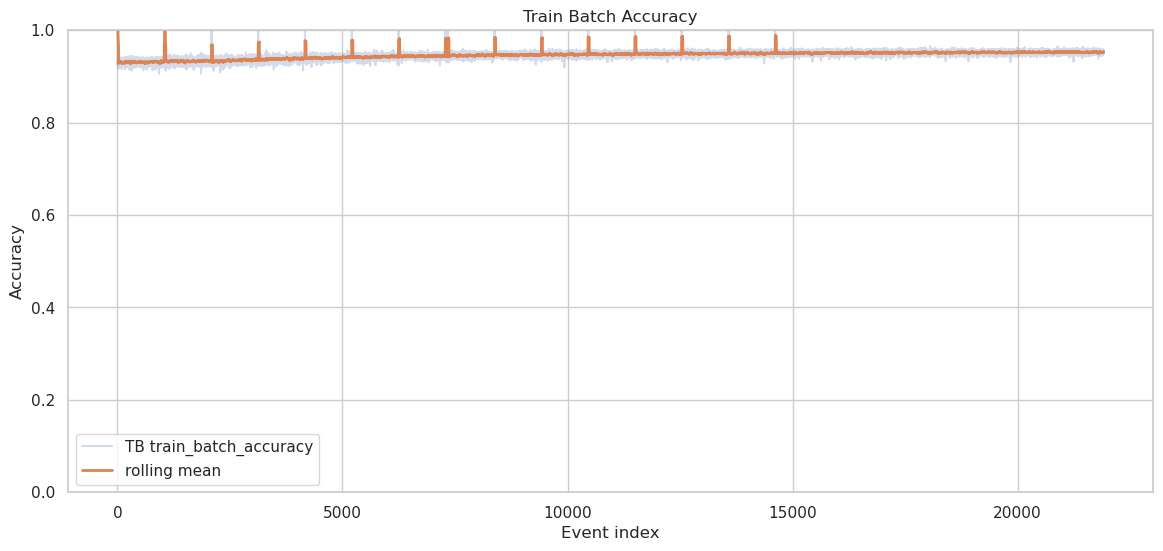

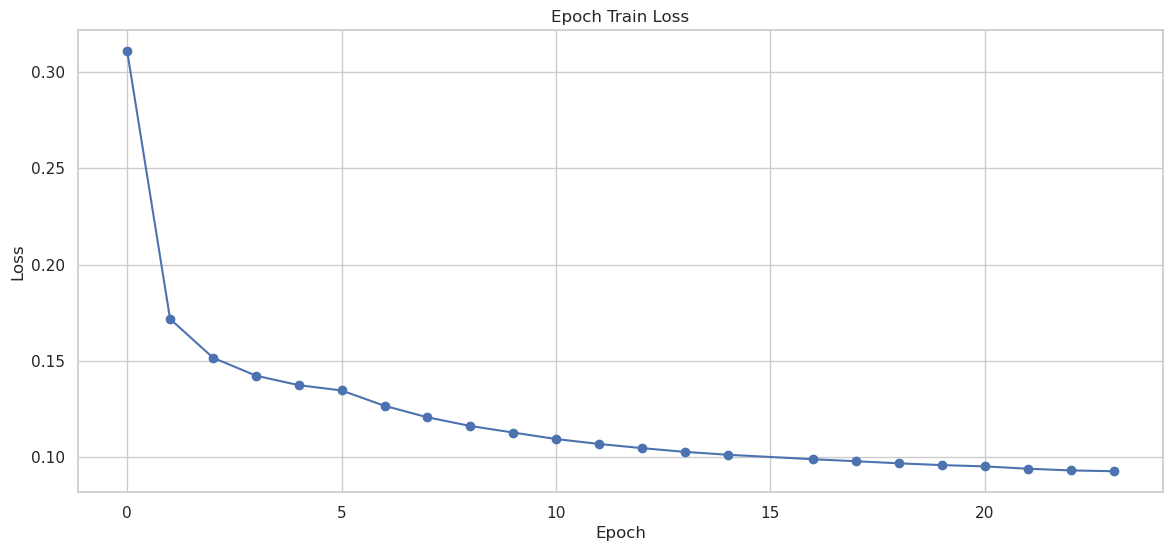

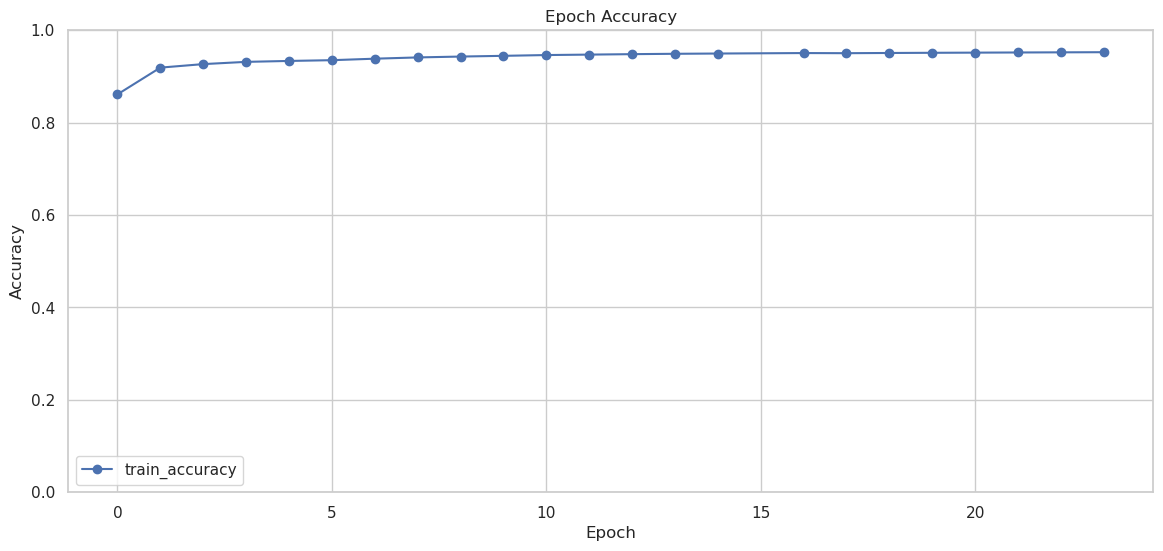

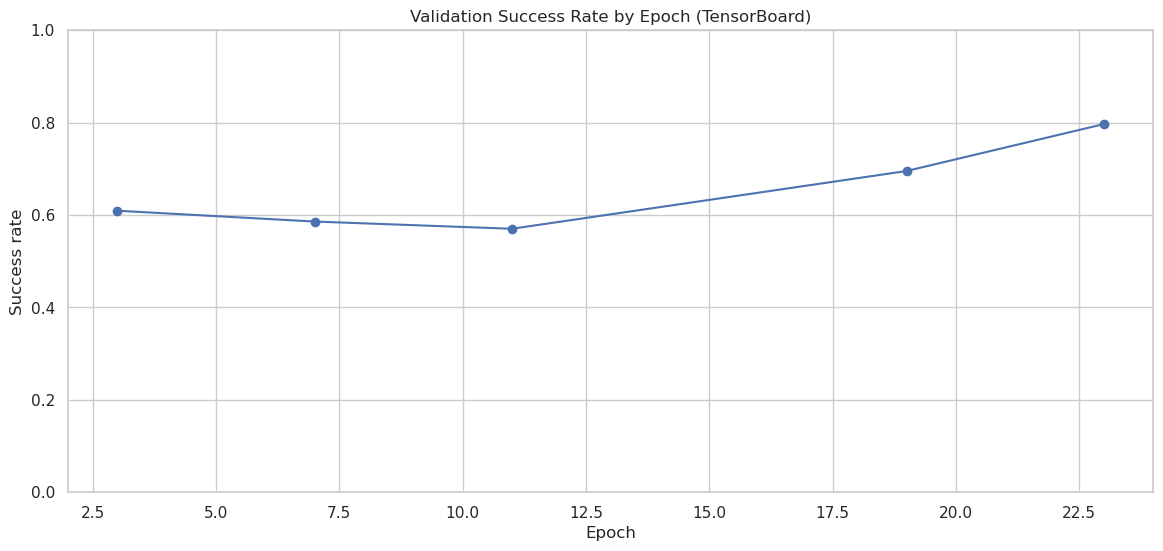

In [13]:
if tb_df.empty:
    print("TensorBoard event files do not contain scalar data yet.")
else:
    tb_train_batch_loss_df = tb_df[tb_df["tag"] == "train_batch_loss"].copy()
    tb_train_batch_accuracy_df = tb_df[tb_df["tag"] == "train_batch_accuracy"].copy()
    tb_epoch_df = tb_df[tb_df["tag"].isin(["train_loss", "train_accuracy", "validation_accuracy", "validation_success_rate"])].copy()
    if not tb_epoch_df.empty:
        tb_epoch_df = tb_epoch_df.sort_values(["tag", "event_step", "wall_time", "event_file"]).drop_duplicates(["tag", "event_step"], keep="last")

    if not tb_train_batch_loss_df.empty:
        tb_train_batch_loss_df["rolling_25"] = tb_train_batch_loss_df["value"].rolling(window=25, min_periods=1).mean()
        fig, ax = plt.subplots()
        ax.plot(tb_train_batch_loss_df["event_index"], tb_train_batch_loss_df["value"], alpha=0.25, label="TB train_batch_loss")
        ax.plot(tb_train_batch_loss_df["event_index"], tb_train_batch_loss_df["rolling_25"], linewidth=2, label="rolling mean")
        ax.set_title("Train Batch Loss")
        ax.set_xlabel("Event index")
        ax.set_ylabel("Loss")
        ax.legend()
        plt.show()
    else:
        print("TensorBoard train_batch_loss is not available yet.")

    if not tb_train_batch_accuracy_df.empty:
        tb_train_batch_accuracy_df["rolling_25"] = tb_train_batch_accuracy_df["value"].rolling(window=25, min_periods=1).mean()
        fig, ax = plt.subplots()
        ax.plot(tb_train_batch_accuracy_df["event_index"], tb_train_batch_accuracy_df["value"], alpha=0.25, label="TB train_batch_accuracy")
        ax.plot(tb_train_batch_accuracy_df["event_index"], tb_train_batch_accuracy_df["rolling_25"], linewidth=2, label="rolling mean")
        ax.set_title("Train Batch Accuracy")
        ax.set_xlabel("Event index")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.0, 1.0)
        ax.legend()
        plt.show()
    else:
        print("TensorBoard train_batch_accuracy is not available yet.")

    if tb_epoch_df.empty:
        print("Epoch-level train/validation metrics are not available yet.")
    else:
        epoch_train_loss_df = tb_epoch_df[tb_epoch_df["tag"] == "train_loss"]
        if not epoch_train_loss_df.empty:
            fig, ax = plt.subplots()
            ax.plot(epoch_train_loss_df["event_step"], epoch_train_loss_df["value"], marker="o")
            ax.set_title("Epoch Train Loss")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            plt.show()

        epoch_train_accuracy_df = tb_epoch_df[tb_epoch_df["tag"] == "train_accuracy"]
        epoch_validation_accuracy_df = tb_epoch_df[tb_epoch_df["tag"] == "validation_accuracy"]
        if not epoch_train_accuracy_df.empty or not epoch_validation_accuracy_df.empty:
            fig, ax = plt.subplots()
            if not epoch_train_accuracy_df.empty:
                ax.plot(epoch_train_accuracy_df["event_step"], epoch_train_accuracy_df["value"], marker="o", label="train_accuracy")
            # if not epoch_validation_accuracy_df.empty:
            #     ax.plot(epoch_validation_accuracy_df["event_step"], epoch_validation_accuracy_df["value"], marker="s", label="validation_accuracy")
            ax.set_title("Epoch Accuracy")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Accuracy")
            ax.set_ylim(0.0, 1.0)
            ax.legend()
            plt.show()

        epoch_validation_success_df = tb_epoch_df[tb_epoch_df["tag"] == "validation_success_rate"]
        if not epoch_validation_success_df.empty:
            fig, ax = plt.subplots()
            ax.plot(epoch_validation_success_df["event_step"], epoch_validation_success_df["value"], marker="o")
            ax.set_title("Validation Success Rate by Epoch (TensorBoard)")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Success rate")
            ax.set_ylim(0.0, 1.0)
            plt.show()


accuracy = число правильно предсказанных действий / общее число expert-действий в батче


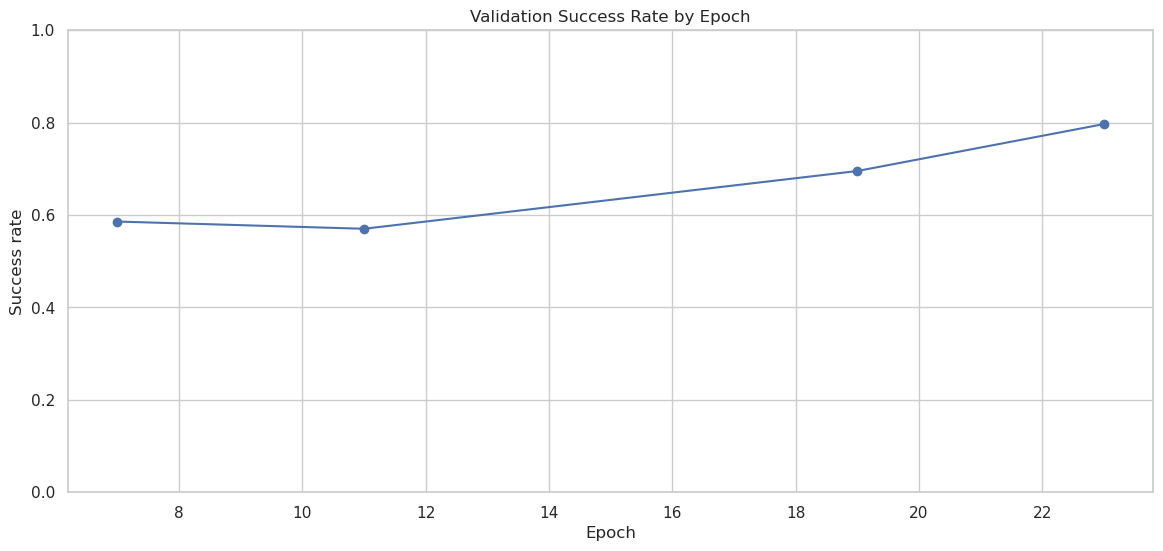

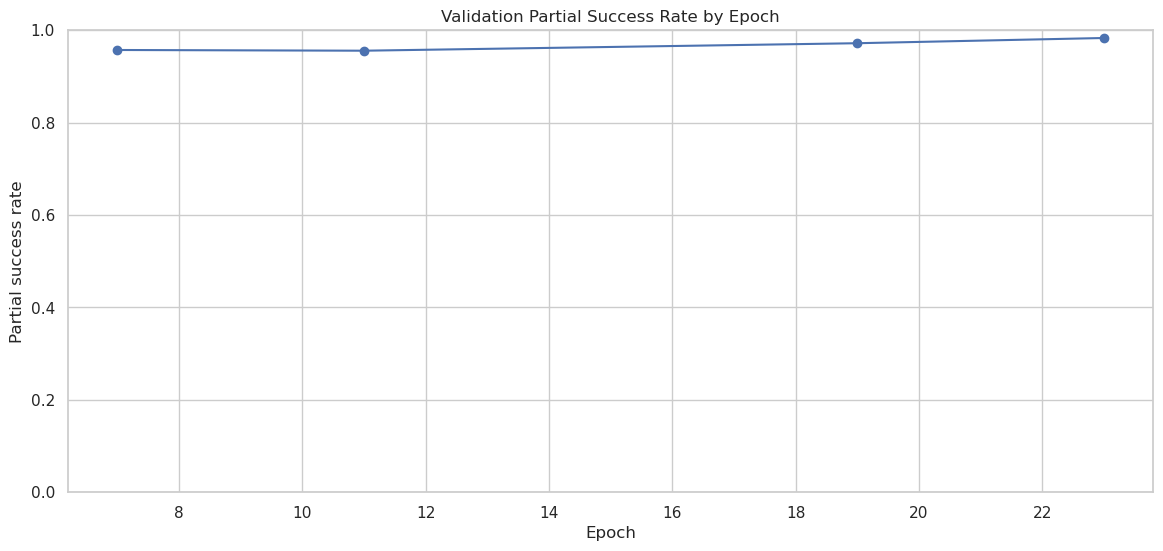

,epoch,train_loss,train_accuracy,validation_accuracy_x,validation_success_rate_x,validation_accuracy_y,validation_success_rate_y,validation_average_partial_success_rate
0,0,0.310706,0.861177,NaN,NaN,NaN,NaN,NaN
1,1,0.171820,0.919110,NaN,NaN,NaN,NaN,NaN
2,2,0.151707,0.926706,NaN,NaN,NaN,NaN,NaN
3,3,0.142392,0.931567,0.930566,0.609375,NaN,NaN,NaN
4,4,0.137460,0.933574,NaN,NaN,NaN,NaN,NaN
5,5,0.134695,0.935200,NaN,NaN,NaN,NaN,NaN
6,6,0.126754,0.938450,NaN,NaN,NaN,NaN,NaN
7,7,0.120788,0.941171,0.939460,0.585938,0.939460,0.585938,0.957275
8,8,0.116287,0.943057,NaN,NaN,NaN,NaN,NaN
9,9,0.112869,0.944632,NaN,NaN,NaN,NaN,NaN


In [14]:
# Validation success-rate, partial-success, and merged epoch-level summary

validation_success_df = pd.DataFrame(columns=["epoch", "validation_success_rate"])
validation_partial_success_df = pd.DataFrame(columns=["epoch", "validation_average_partial_success_rate"])

if not validation_metrics_df.empty:
    if "validation_success_rate" in validation_metrics_df.columns:
        validation_success_df = validation_metrics_df[["epoch", "validation_success_rate"]].copy()
        validation_success_df["validation_success_rate"] = pd.to_numeric(
            validation_success_df["validation_success_rate"], errors="coerce"
        )
    if "validation_average_partial_success_rate" in validation_metrics_df.columns:
        validation_partial_success_df = validation_metrics_df[["epoch", "validation_average_partial_success_rate"]].copy()
        validation_partial_success_df["validation_average_partial_success_rate"] = pd.to_numeric(
            validation_partial_success_df["validation_average_partial_success_rate"], errors="coerce"
        )
elif 'tb_epoch_df' in globals() and not tb_epoch_df.empty:
    validation_success_df = tb_epoch_df[tb_epoch_df["tag"] == "validation_success_rate"][["event_step", "value"]].copy()
    validation_success_df = validation_success_df.rename(columns={"event_step": "epoch", "value": "validation_success_rate"})

if not validation_success_df.empty and not validation_success_df["validation_success_rate"].dropna().empty:
    validation_success_df = validation_success_df.sort_values("epoch").drop_duplicates("epoch", keep="last")
    fig, ax = plt.subplots()
    ax.plot(validation_success_df["epoch"], validation_success_df["validation_success_rate"], marker="o")
    ax.set_title("Validation Success Rate by Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Success rate")
    ax.set_ylim(0.0, 1.0)
    plt.show()
else:
    print("Validation success rate is not available yet as epoch-level series.")

if not validation_partial_success_df.empty and not validation_partial_success_df["validation_average_partial_success_rate"].dropna().empty:
    validation_partial_success_df = validation_partial_success_df.sort_values("epoch").drop_duplicates("epoch", keep="last")
    fig, ax = plt.subplots()
    ax.plot(validation_partial_success_df["epoch"], validation_partial_success_df["validation_average_partial_success_rate"], marker="o")
    ax.set_title("Validation Partial Success Rate by Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Partial success rate")
    ax.set_ylim(0.0, 1.0)
    plt.show()
else:
    print("Validation partial success rate is not available yet as epoch-level series.")

epoch_metrics_df = pd.DataFrame(columns=["epoch"])

if not epoch_summary_df.empty:
    csv_epoch_df = epoch_summary_df[["epoch", "mean_train_loss", "mean_train_accuracy"]].copy()
    csv_epoch_df = csv_epoch_df.rename(columns={
        "mean_train_loss": "train_loss",
        "mean_train_accuracy": "train_accuracy",
    })
    epoch_metrics_df = csv_epoch_df

if 'tb_epoch_df' in globals() and not tb_epoch_df.empty:
    tb_epoch_wide_df = tb_epoch_df[["tag", "event_step", "value"]].copy()
    tb_epoch_wide_df = tb_epoch_wide_df.rename(columns={"event_step": "epoch"})
    tb_epoch_wide_df = tb_epoch_wide_df.pivot(index="epoch", columns="tag", values="value").reset_index()
    if epoch_metrics_df.empty:
        epoch_metrics_df = tb_epoch_wide_df
    else:
        epoch_metrics_df = epoch_metrics_df.merge(tb_epoch_wide_df, on="epoch", how="outer", suffixes=("", "_tb"))
        if "train_loss_tb" in epoch_metrics_df.columns:
            epoch_metrics_df["train_loss"] = epoch_metrics_df["train_loss"].combine_first(epoch_metrics_df["train_loss_tb"])
            epoch_metrics_df = epoch_metrics_df.drop(columns=["train_loss_tb"])
        if "train_accuracy_tb" in epoch_metrics_df.columns:
            epoch_metrics_df["train_accuracy"] = epoch_metrics_df["train_accuracy"].combine_first(epoch_metrics_df["train_accuracy_tb"])
            epoch_metrics_df = epoch_metrics_df.drop(columns=["train_accuracy_tb"])

if not validation_metrics_df.empty:
    val_epoch_cols = [
        col for col in [
            "epoch",
            "validation_accuracy",
            "validation_success_rate",
            "validation_average_partial_success_rate",
        ] if col in validation_metrics_df.columns
    ]
    val_epoch_df = validation_metrics_df[val_epoch_cols].copy()
    if epoch_metrics_df.empty:
        epoch_metrics_df = val_epoch_df
    else:
        epoch_metrics_df = epoch_metrics_df.merge(val_epoch_df, on="epoch", how="outer")

if not epoch_metrics_df.empty:
    epoch_metrics_df = epoch_metrics_df.sort_values("epoch").drop_duplicates("epoch", keep="last")

epoch_metrics_df


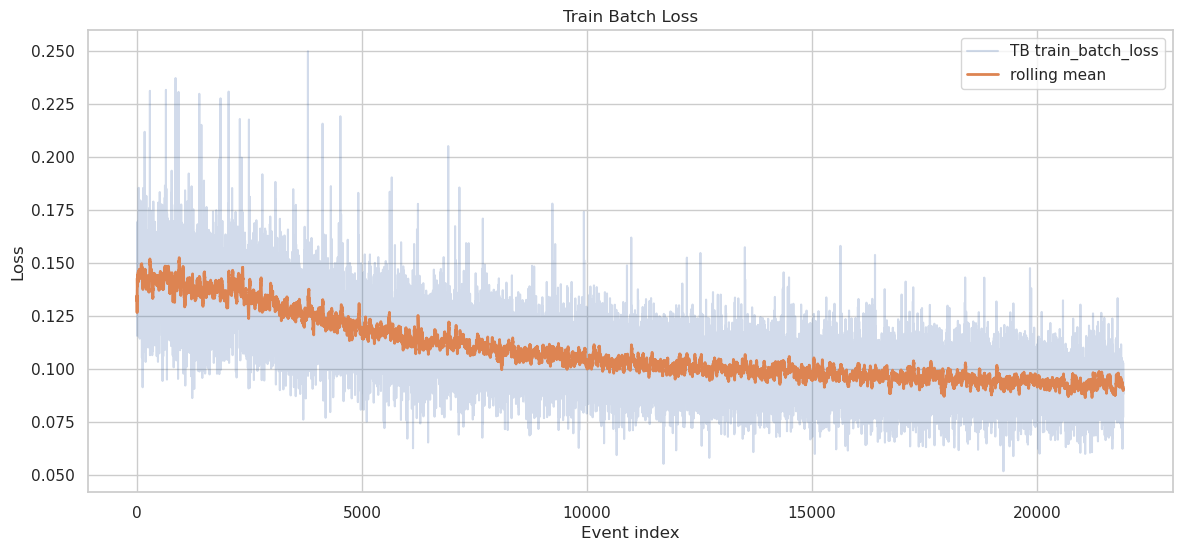

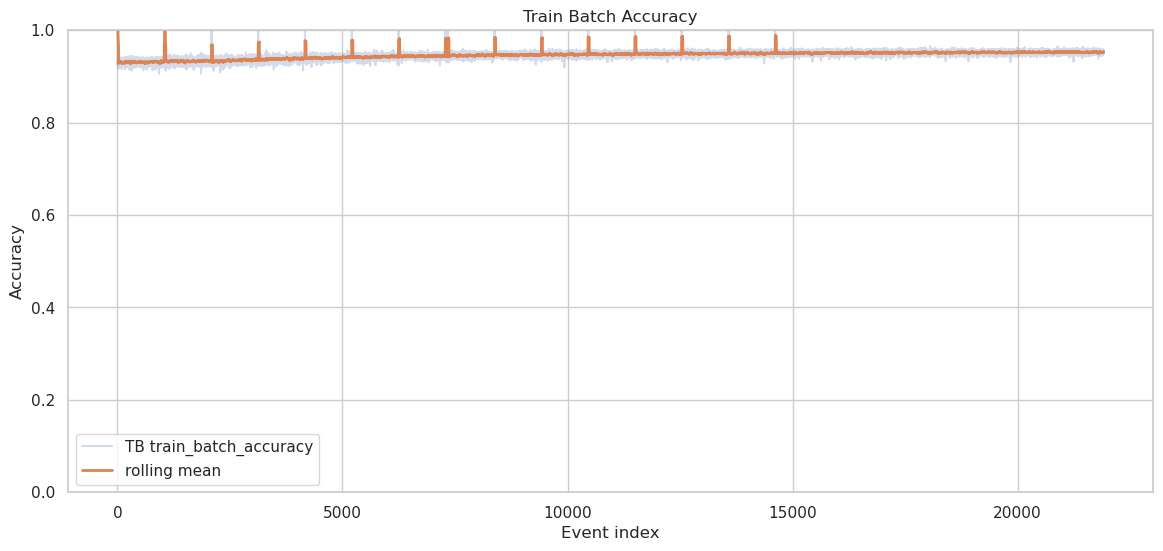

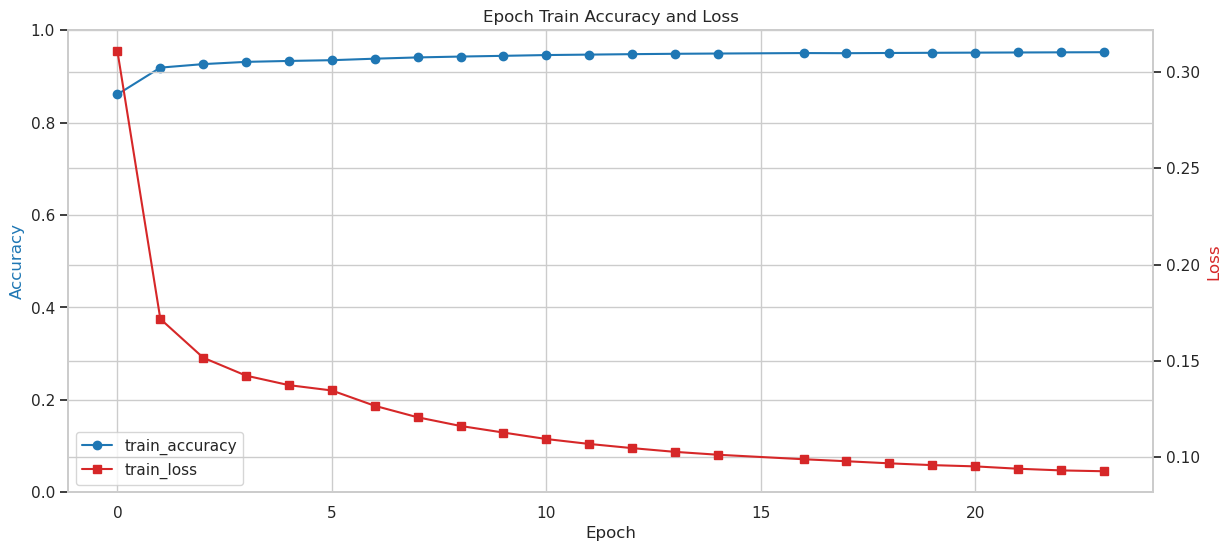

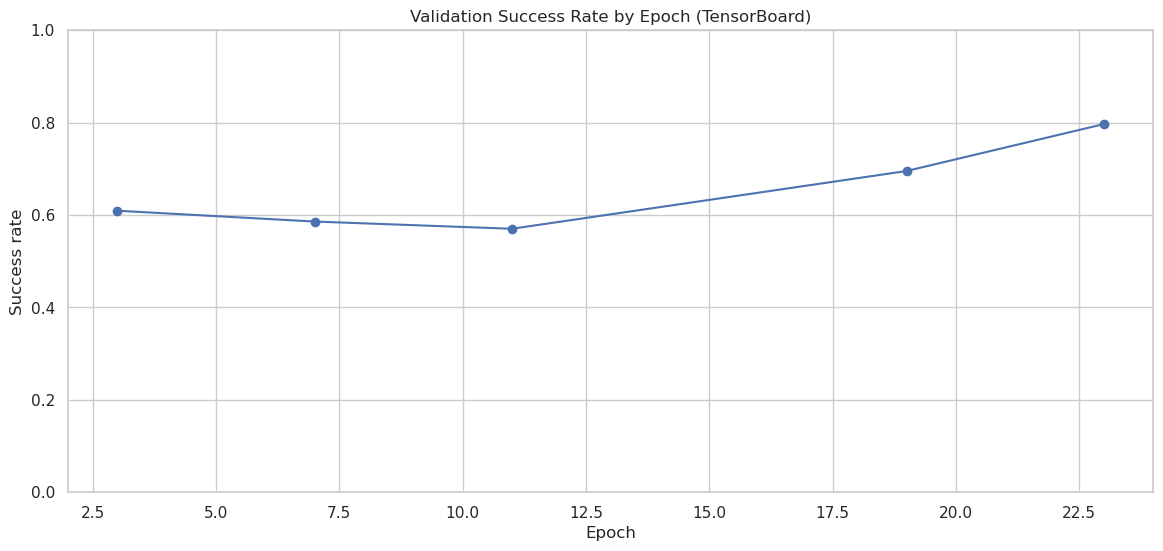

In [15]:
if tb_df.empty:
    print("TensorBoard event files do not contain scalar data yet.")
else:
    tb_train_batch_loss_df = tb_df[tb_df["tag"] == "train_batch_loss"].copy()
    tb_train_batch_accuracy_df = tb_df[tb_df["tag"] == "train_batch_accuracy"].copy()
    tb_epoch_df = tb_df[
        tb_df["tag"].isin(
            ["train_loss", "train_accuracy", "validation_accuracy", "validation_success_rate"]
        )
    ].copy()
    if not tb_epoch_df.empty:
        tb_epoch_df = (
            tb_epoch_df
            .sort_values(["tag", "event_step", "wall_time", "event_file"])
            .drop_duplicates(["tag", "event_step"], keep="last")
        )

    if not tb_train_batch_loss_df.empty:
        tb_train_batch_loss_df["rolling_25"] = (
            tb_train_batch_loss_df["value"].rolling(window=25, min_periods=1).mean()
        )
        fig, ax = plt.subplots()
        ax.plot(
            tb_train_batch_loss_df["event_index"],
            tb_train_batch_loss_df["value"],
            alpha=0.25,
            label="TB train_batch_loss",
        )
        ax.plot(
            tb_train_batch_loss_df["event_index"],
            tb_train_batch_loss_df["rolling_25"],
            linewidth=2,
            label="rolling mean",
        )
        ax.set_title("Train Batch Loss")
        ax.set_xlabel("Event index")
        ax.set_ylabel("Loss")
        ax.legend()
        plt.show()
    else:
        print("TensorBoard train_batch_loss is not available yet.")

    if not tb_train_batch_accuracy_df.empty:
        tb_train_batch_accuracy_df["rolling_25"] = (
            tb_train_batch_accuracy_df["value"].rolling(window=25, min_periods=1).mean()
        )
        fig, ax = plt.subplots()
        ax.plot(
            tb_train_batch_accuracy_df["event_index"],
            tb_train_batch_accuracy_df["value"],
            alpha=0.25,
            label="TB train_batch_accuracy",
        )
        ax.plot(
            tb_train_batch_accuracy_df["event_index"],
            tb_train_batch_accuracy_df["rolling_25"],
            linewidth=2,
            label="rolling mean",
        )
        ax.set_title("Train Batch Accuracy")
        ax.set_xlabel("Event index")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0.0, 1.0)
        ax.legend()
        plt.show()
    else:
        print("TensorBoard train_batch_accuracy is not available yet.")

    if tb_epoch_df.empty:
        print("Epoch-level train/validation metrics are not available yet.")
    else:
        epoch_train_loss_df = tb_epoch_df[tb_epoch_df["tag"] == "train_loss"].copy()
        epoch_train_accuracy_df = tb_epoch_df[tb_epoch_df["tag"] == "train_accuracy"].copy()

        if not epoch_train_loss_df.empty or not epoch_train_accuracy_df.empty:
            fig, ax_left = plt.subplots()
            ax_right = ax_left.twinx()

            left_lines = []
            right_lines = []

            if not epoch_train_accuracy_df.empty:
                line_acc, = ax_left.plot(
                    epoch_train_accuracy_df["event_step"],
                    epoch_train_accuracy_df["value"],
                    marker="o",
                    color="tab:blue",
                    label="train_accuracy",
                )
                left_lines.append(line_acc)

            if not epoch_train_loss_df.empty:
                line_loss, = ax_right.plot(
                    epoch_train_loss_df["event_step"],
                    epoch_train_loss_df["value"],
                    marker="s",
                    color="tab:red",
                    label="train_loss",
                )
                right_lines.append(line_loss)

            ax_left.set_title("Epoch Train Accuracy and Loss")
            ax_left.set_xlabel("Epoch")
            ax_left.set_ylabel("Accuracy", color="tab:blue")
            ax_left.set_ylim(0.0, 1.0)
            ax_right.set_ylabel("Loss", color="tab:red")

            lines = left_lines + right_lines
            labels = [line.get_label() for line in lines]
            ax_left.legend(lines, labels, loc="best")

            plt.show()

        epoch_validation_success_df = tb_epoch_df[
            tb_epoch_df["tag"] == "validation_success_rate"
        ]
        if not epoch_validation_success_df.empty:
            fig, ax = plt.subplots()
            ax.plot(
                epoch_validation_success_df["event_step"],
                epoch_validation_success_df["value"],
                marker="o",
            )
            ax.set_title("Validation Success Rate by Epoch (TensorBoard)")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Success rate")
            ax.set_ylim(0.0, 1.0)
            plt.show()

In [16]:
OUTPUT_DIR = PROJECT_ROOT / "outputs"
SUCCESS_SWEEP_CANDIDATES = sorted(
    path
    for path in OUTPUT_DIR.glob("*success_sweep*.csv")
    if not path.name.endswith("_summary.csv")
)
SUCCESS_SWEEP_CSV = (
    SUCCESS_SWEEP_CANDIDATES[-1]
    if SUCCESS_SWEEP_CANDIDATES
    else OUTPUT_DIR / "demo_success_sweep_epoch15.csv"
)
SUCCESS_SWEEP_SUMMARY_CSV = SUCCESS_SWEEP_CSV.with_name(
    f"{SUCCESS_SWEEP_CSV.stem}_summary.csv"
)

SUCCESS_SWEEP_CSV, SUCCESS_SWEEP_SUMMARY_CSV

(PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/outputs/demo_success_sweep_epoch23.csv'),
 PosixPath('/home/work/WORK/MIPT/study/repos/heuristics/hmagat/outputs/demo_success_sweep_epoch23_summary.csv'))

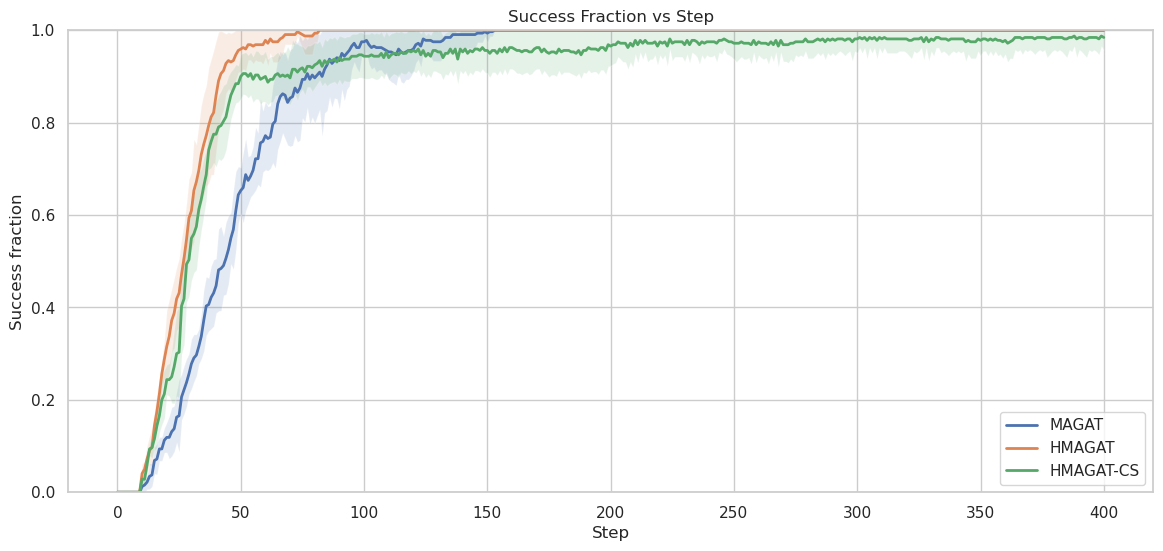

In [17]:
if not SUCCESS_SWEEP_CSV.exists():
    print(f"Success sweep CSV not found yet: {SUCCESS_SWEEP_CSV}")
else:
    success_steps_df = pd.read_csv(SUCCESS_SWEEP_CSV)
    success_curve_df = (
        success_steps_df.groupby(["model", "step"], as_index=False)["success_fraction"]
        .agg(mean="mean", std="std", count="size")
        .sort_values(["model", "step"])
    )
    success_curve_df["std"] = success_curve_df["std"].fillna(0.0)

    model_order = ["MAGAT", "HMAGAT", "HMAGAT-CS"]
    model_order = [model for model in model_order if model in set(success_curve_df["model"])]
    remaining_models = [
        model for model in success_curve_df["model"].unique() if model not in model_order
    ]
    model_order.extend(sorted(remaining_models))

    fig, ax = plt.subplots()
    for model in model_order:
        model_df = success_curve_df[success_curve_df["model"] == model].copy()
        lower = (model_df["mean"] - model_df["std"]).clip(lower=0.0)
        upper = (model_df["mean"] + model_df["std"]).clip(upper=1.0)
        ax.plot(model_df["step"], model_df["mean"], linewidth=2, label=model)
        ax.fill_between(model_df["step"], lower, upper, alpha=0.15)

    ax.set_title("Success Fraction vs Step")
    ax.set_xlabel("Step")
    ax.set_ylabel("Success fraction")
    ax.set_ylim(0.0, 1.0)
    ax.legend()
    plt.show()

In [ ]:
if not SUCCESS_SWEEP_CSV.exists():
    print(f"Success sweep CSV not found yet: {SUCCESS_SWEEP_CSV}")
else:
    success_steps_df = pd.read_csv(SUCCESS_SWEEP_CSV)
    if SUCCESS_SWEEP_SUMMARY_CSV.exists():
        success_summary_df = pd.read_csv(SUCCESS_SWEEP_SUMMARY_CSV)
    else:
        success_summary_df = (
            success_steps_df.sort_values(["model", "sampling_seed", "step"])
            .groupby(["model", "sampling_seed"], as_index=False)
            .tail(1)
            [["model", "sampling_seed", "success_fraction", "rollout_success", "makespan"]]
            .rename(columns={"success_fraction": "final_success_fraction"})
        )

    display(success_summary_df.sort_values(["model", "sampling_seed"]).reset_index(drop=True))

    summary_agg_df = (
        success_summary_df.groupby("model", as_index=False)
        .agg(
            runs=("sampling_seed", "size"),
            mean_final_success=("final_success_fraction", "mean"),
            std_final_success=("final_success_fraction", "std"),
            mean_rollout_success=("rollout_success", "mean"),
            std_rollout_success=("rollout_success", "std"),
            mean_makespan=("makespan", "mean"),
            std_makespan=("makespan", "std"),
        )
        .sort_values("model")
    )
    summary_agg_df[[
        "std_final_success",
        "std_rollout_success",
        "std_makespan",
    ]] = summary_agg_df[[
        "std_final_success",
        "std_rollout_success",
        "std_makespan",
    ]].fillna(0.0)

    display(summary_agg_df.reset_index(drop=True))